Imports

In [63]:
%pip install pandas numpy matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, mean_squared_error,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score,
                             brier_score_loss, log_loss,
                             roc_curve, roc_auc_score,
                             precision_recall_curve, average_precision_score,
                             silhouette_score, f1_score, recall_score, precision_score)
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              AdaBoostClassifier,
                              StackingClassifier, HistGradientBoostingClassifier)
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Consistent aesthetics
plt.rcParams.update({
    'figure.dpi': 120,
    'font.family': 'sans-serif',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


load and clean

In [64]:
# --- Load ---
# The CSV has a two-row header: row 0 names the pathogen group,
# row 1 provides the year label. We skip row 0 and assign names manually.
df = pd.read_csv('ThreeYearVirusData.csv', skiprows=1)

df.columns = [
    'Sample_Name', 'Location', 'Cultivar', 'Block', 'Tree_Number', 'Row', 'Tree',
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]

print(f"Shape: {df.shape}")
df.head(3)


Shape: (2408, 16)


,Sample_Name,Location,Cultivar,Block,Tree_Number,Row,Tree,PDV_Y1,PDV_Y2,PDV_Y3,PNRSV_Y1,PNRSV_Y2,PNRSV_Y3,PLMVd_Y1,PLMVd_Y2,PLMVd_Y3
0,AP B-1 5351,Edgefield,Augustprince,B-1,5351,1,10,-,-,-,-,-,-,-,-,-
1,AP B-1 5352,Edgefield,Augustprince,B-1,5352,1,9,-,-,-,-,-,-,-,-,-
2,AP B-1 5353,Edgefield,Augustprince,B-1,5353,1,8,-,-,-,-,-,-,-,-,-


In [65]:
# --- Binary-encode the 9 virus test columns (+/- -> 1/0) ---
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    df[col + '_bin'] = (df[col] == '+').astype(int)

# --- Encode Location ---z
le_loc = LabelEncoder()
df['Location_enc'] = le_loc.fit_transform(df['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = df['Cultivar'].value_counts().head(10).index.tolist()
df['Cultivar_grp'] = df['Cultivar'].apply(lambda x: x if x in top10_cultivars else 'Other')
le_cult = LabelEncoder()
df['Cultivar_enc'] = le_cult.fit_transform(df['Cultivar_grp'])

# --- Numeric position columns ---
df['Row_num']  = pd.to_numeric(df['Row'],  errors='coerce').fillna(df['Row'].value_counts().index[0])
df['Tree_num'] = pd.to_numeric(df['Tree'], errors='coerce').fillna(0)

print("Missing values:", df.isnull().sum().sum())
print("Class distribution â€” PLMVd Year 3:")
print(df['PLMVd_Y3_bin'].value_counts().rename({0:'Negative', 1:'Positive'}))


Missing values: 21
Class distribution â€” PLMVd Year 3:
PLMVd_Y3_bin
Negative    2263
Positive     145
Name: count, dtype: int64


Feature Matrix

In [66]:
# Features used for clustering and dimensionality reduction.
# We include all available prior-year virus data plus metadata.
# PLMVd_Y3_bin is the TARGET â€” kept in df for coloring but NOT in X.
FEATURE_COLS = [
    'PLMVd_Y1_bin', 'PLMVd_Y2_bin',
    'PDV_Y1_bin',   'PDV_Y2_bin',
    'PNRSV_Y1_bin', 'PNRSV_Y2_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_raw = df[FEATURE_COLS].values
y     = df['PLMVd_Y3_bin'].values  # used only for coloring

# Standardize
scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(f"Feature matrix: {X.shape}")
print(f"Positive (PLMVd Y3): {y.sum()} / {len(y)}  ({y.mean()*100:.1f}%)")


Feature matrix: (2408, 10)
Positive (PLMVd Y3): 145 / 2408  (6.0%)


In [67]:
n_samples, n_features = X.shape

pca = PCA(n_components=7)
X_transformed = pca.fit_transform(X)

print(f"{7} principal components explain {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance.")

# We center the data and compute the sample covariance matrix.
X_centered = X - np.mean(X, axis=0)
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
eigenvalues = pca.explained_variance_
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, pca.components_)):
    print(f"\nPC{i+1} â€” eigenvalue: {eigenvalue:.6f}")
    print(f"  verification dot product: {np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)):.6f}")
    for feature, loading in zip(FEATURE_COLS, eigenvector):
        print(f"  {feature}: {loading:.6f}")

7 principal components explain 90.76% of the variance.

PC1 â€” eigenvalue: 2.529481
  verification dot product: 2.528431
  PLMVd_Y1_bin: -0.078959
  PLMVd_Y2_bin: -0.049347
  PDV_Y1_bin: 0.546011
  PDV_Y2_bin: 0.543127
  PNRSV_Y1_bin: 0.302569
  PNRSV_Y2_bin: 0.368080
  Location_enc: -0.232562
  Cultivar_enc: 0.167357
  Row_num: -0.217887
  Tree_num: -0.204002

PC2 â€” eigenvalue: 1.720199
  verification dot product: 1.719485
  PLMVd_Y1_bin: 0.548946
  PLMVd_Y2_bin: 0.494504
  PDV_Y1_bin: 0.079002
  PDV_Y2_bin: 0.070512
  PNRSV_Y1_bin: 0.231469
  PNRSV_Y2_bin: 0.216561
  Location_enc: 0.256970
  Cultivar_enc: 0.226221
  Row_num: 0.332693
  Tree_num: 0.338440

PC3 â€” eigenvalue: 1.397845
  verification dot product: 1.397264
  PLMVd_Y1_bin: 0.407273
  PLMVd_Y2_bin: 0.516783
  PDV_Y1_bin: -0.066535
  PDV_Y2_bin: -0.065216
  PNRSV_Y1_bin: -0.156444
  PNRSV_Y2_bin: -0.175564
  Location_enc: -0.338315
  Cultivar_enc: -0.095025
  Row_num: -0.336304
  Tree_num: -0.516237

PC4 â€” eigenvalue:

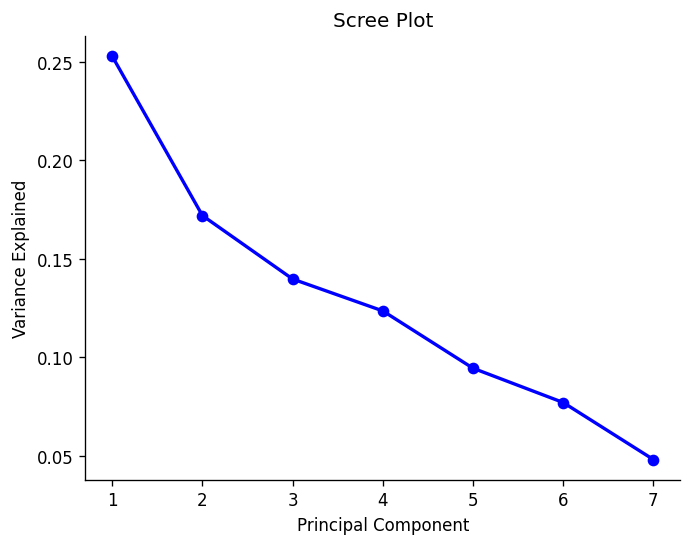

In [68]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

Split data for pca analysis

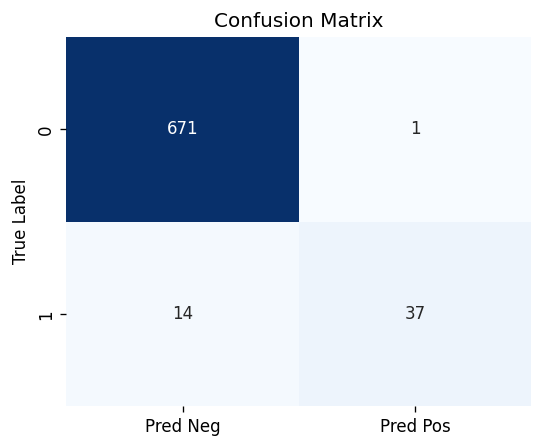

In [69]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],)
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

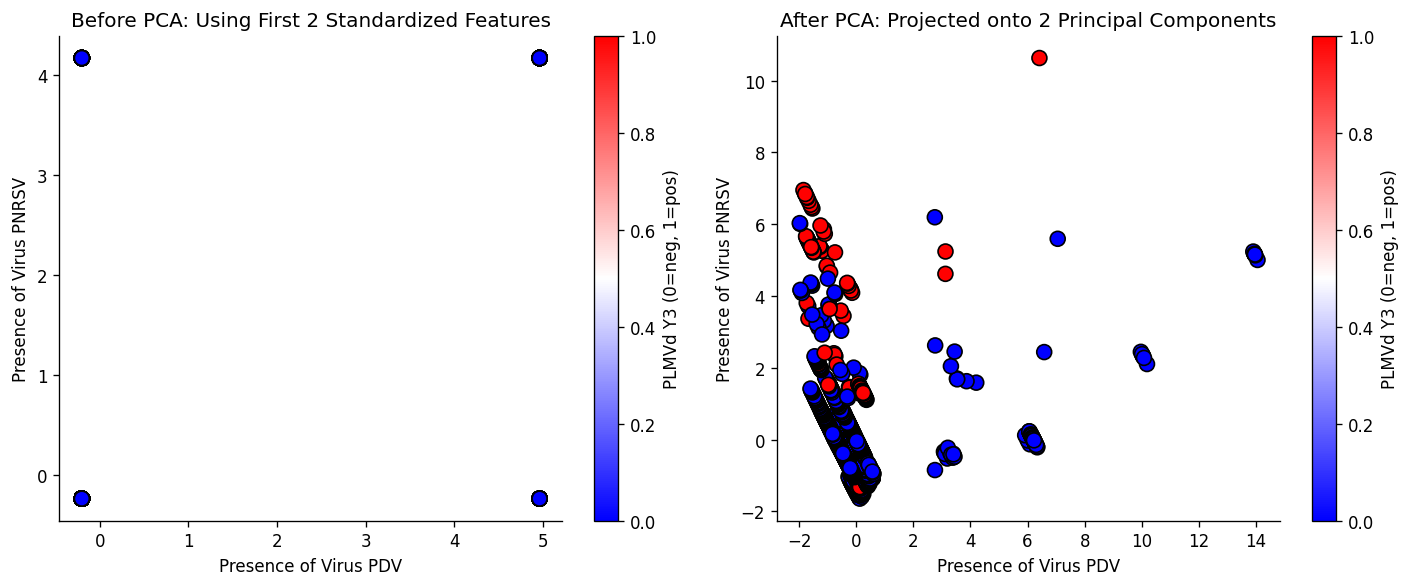

In [70]:
y_numeric = pd.factorize(y)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('Presence of Virus PDV')
plt.ylabel('Presence of Virus PNRSV')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='PLMVd Y3 (0=neg, 1=pos)')

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('Presence of Virus PDV')
plt.ylabel('Presence of Virus PNRSV')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='PLMVd Y3 (0=neg, 1=pos)')

plt.tight_layout()
plt.show()

In [71]:
# Compute Recall
r_data = recall_score(y_test, y_pred)

# Compute Precision
p_data = precision_score(y_test, y_pred)

# Compute F1-Score
f1 = f1_score(y_test, y_pred)

# Print results
print("Recall:", r_data, "\n")
print("Precision:", p_data, "\n")
print("F1-Score:", f1, "\n")

Recall: 0.7254901960784313 

Precision: 0.9736842105263158 

F1-Score: 0.8314606741573034 



In [72]:
from sklearn.decomposition import PCA, FactorAnalysis, KernelPCA
# 1 & 2. Fit Factor Analysis
fa = FactorAnalysis(n_components=8, random_state=42)  # FactorAnalysis
fa.fit(X)

# 3. Noise variance
noise_var = fa.noise_variance_  # np.ndarray of length 36

# 4. FA log-likelihood
fa_score = fa.score(X)  # float

# 5. PCA log-likelihood (for comparison)
pca_8 = PCA(n_components=8)  # PCA
pca_8.fit(X)
pca_score = pca_8.score(X)  # float


print(f"FA average log-likelihood:  {fa_score:.2f}")
print(f"PCA average log-likelihood: {pca_score:.2f}")

FA average log-likelihood:  -12.54
PCA average log-likelihood: -12.84


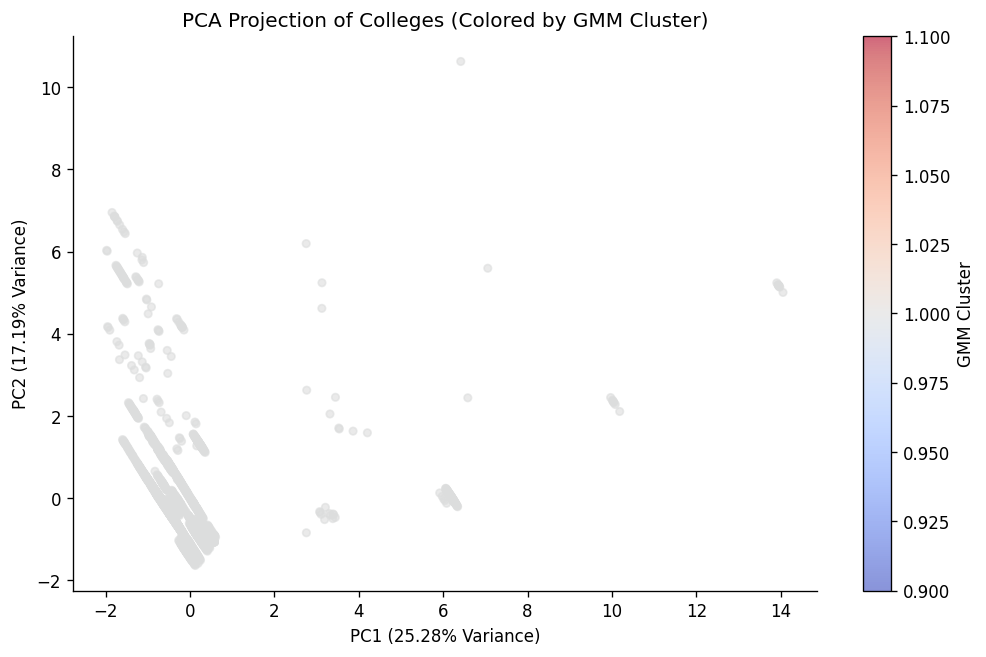

In [73]:
from sklearn.mixture import GaussianMixture
# 1. Scale
scaler_real = StandardScaler()  # StandardScaler
X_scaled_real = scaler_real.fit_transform(X_raw)  # np.ndarray

# 2. PCA (2 Components)
pca_real = PCA(n_components=2)  # PCA
X_pca_real = pca_real.fit_transform(X_scaled_real)  # np.ndarray of shape (N, 2)

# 3. GMM (2 Components) -- fit on full scaled data, not PCA projection
gmm_real = GaussianMixture(n_components=2)  # GaussianMixture
gmm_real.fit(X_raw)
y_gmm_real = gmm_real.predict(X_scaled_real)  # np.ndarray of cluster labels

# YOUR CODE HERE

# Visualization: PCA coordinates, colored by GMM Clusters
plt.figure(figsize=(10, 6))
plt.scatter(X_pca_real[:, 0], X_pca_real[:, 1], c=y_gmm_real, cmap='coolwarm', alpha=0.6, s=20)
plt.title("PCA Projection of Colleges (Colored by GMM Cluster)")
plt.xlabel(f"PC1 ({pca_real.explained_variance_ratio_[0]:.2%} Variance)")
plt.ylabel(f"PC2 ({pca_real.explained_variance_ratio_[1]:.2%} Variance)")
plt.colorbar(label='GMM Cluster')
plt.show()

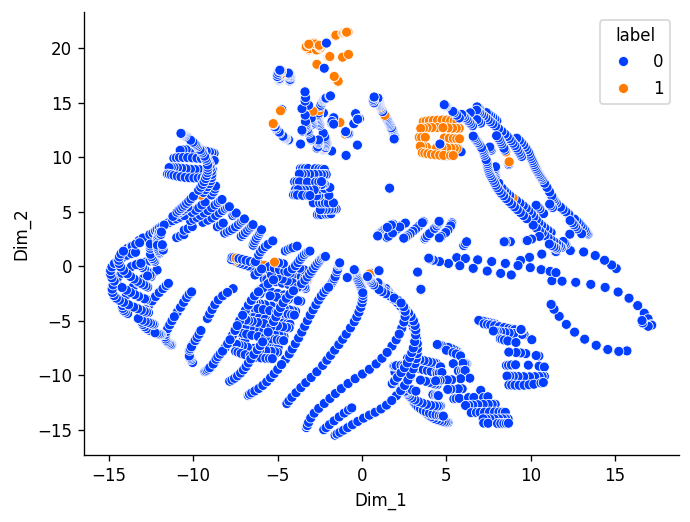

In [74]:
model = TSNE(n_components=3, random_state=42)
tsne_data = model.fit_transform(X)

tsne_df = pd.DataFrame(tsne_data, columns=["Dim_1", "Dim_2", "Dim_3"])
tsne_df["label"] = y

sns.scatterplot(data=tsne_df, x='Dim_1', y='Dim_2',
               hue='label', palette="bright")
plt.show()

Decision Tree

In [75]:
# 1. Initialize
tree_full = DecisionTreeClassifier(random_state=42, min_samples_split=50, min_samples_leaf=20, ccp_alpha=0.0038)  # DecisionTreeClassifier

# 2. Fit
# ...

tree_full.fit(X_train, y_train)

# 3. Calculate Accuracies
train_acc_full = accuracy_score(y_train, tree_full.predict(X_train))  # float
test_acc_full = accuracy_score(y_test,  tree_full.predict(X_test))  # float

# YOUR CODE HERE

print(f"Training Accuracy (Full Tree): {train_acc_full:.4f}")
print(f"Test Accuracy (Full Tree):     {test_acc_full:.4f}")
print(f"Depth of tree: {tree_full.get_depth()}")

Training Accuracy (Full Tree): 0.9846
Test Accuracy (Full Tree):     0.9806
Depth of tree: 1


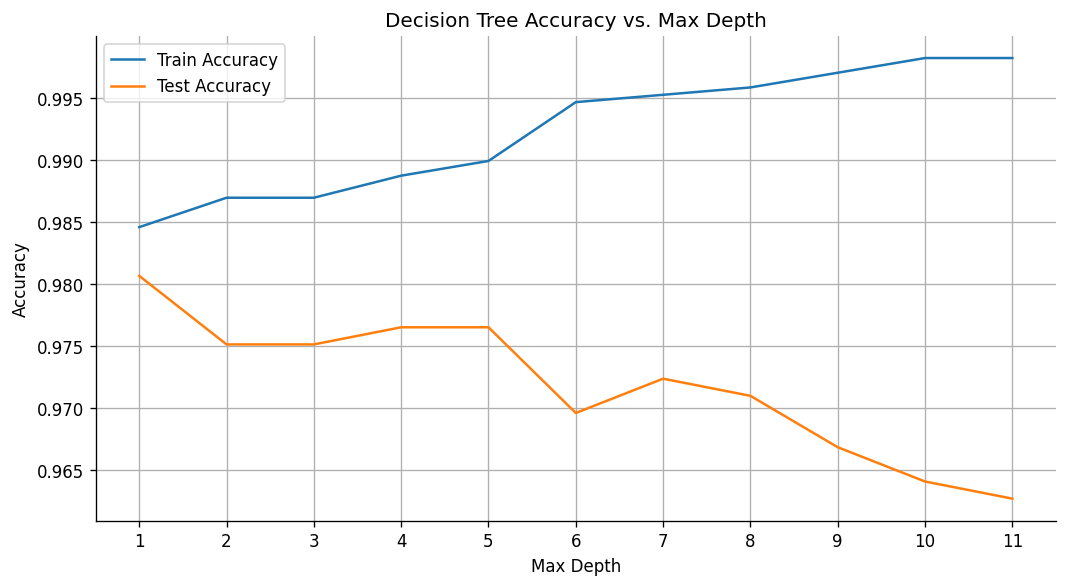

In [76]:
depths = range(1, 12)
train_accs = []
test_accs = []

# 1 & 2. Loop through depths, train, and store accuracies
# ...
for i in depths:
    tree = DecisionTreeClassifier(random_state=42, max_depth=i)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test, tree.predict(X_test)))

# 3. Plot
# ...
plt.figure(figsize=(9, 5))
plt.plot(depths, train_accs, label='Train Accuracy')
plt.plot(depths, test_accs, label='Test Accuracy')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs. Max Depth')
plt.xticks(depths)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

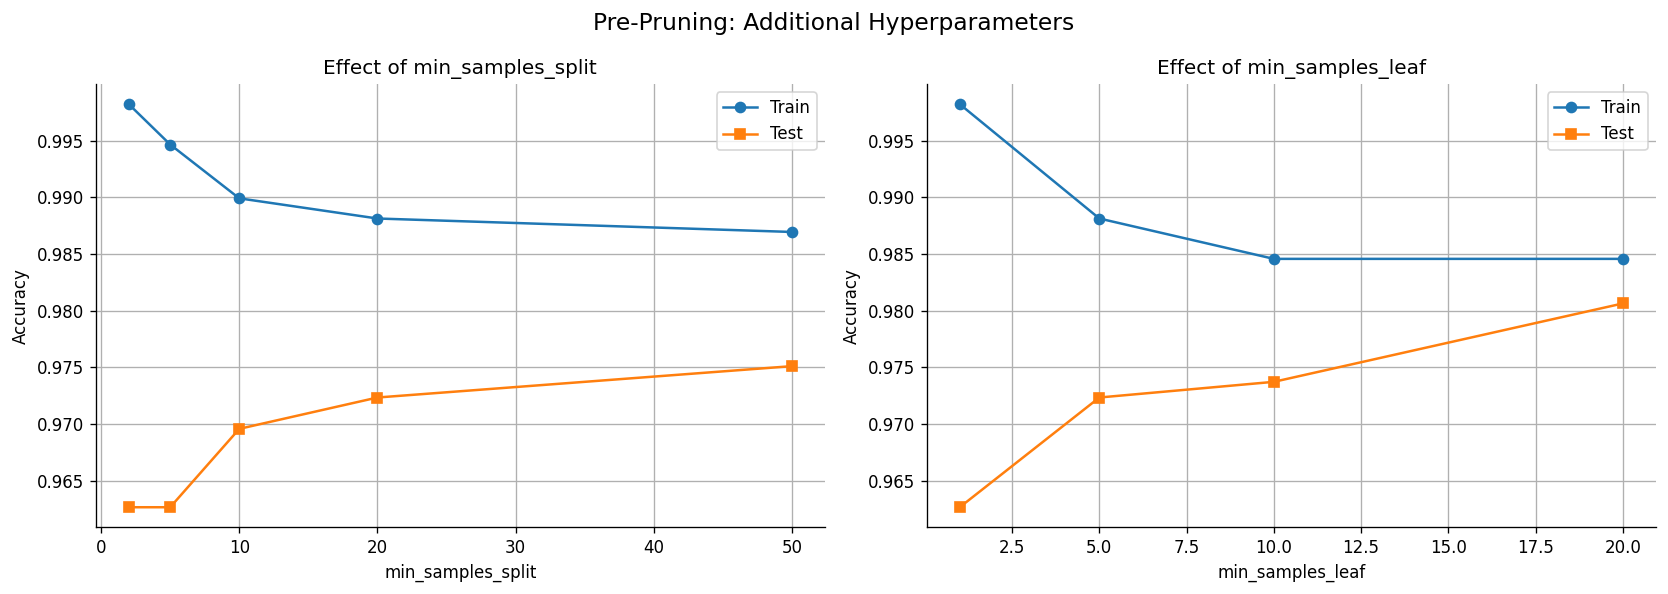

Best min_samples_split: 50
Best min_samples_leaf:  20


In [77]:
split_values = [2, 5, 10, 20, 50]
leaf_values = [1, 5, 10, 20]

train_accs_split = []
test_accs_split = []
train_accs_leaf = []
test_accs_leaf = []

# YOUR CODE HERE
for split in split_values:
    tree = DecisionTreeClassifier(min_samples_split=split, max_depth=None, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_split.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_split.append(accuracy_score(y_test,  tree.predict(X_test)))

for leaf in leaf_values:
    tree = DecisionTreeClassifier(min_samples_leaf=leaf, max_depth=None, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_leaf.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_leaf.append(accuracy_score(y_test,  tree.predict(X_test)))

best_min_split = split_values[np.argmax(test_accs_split)]
best_min_leaf  = leaf_values[np.argmax(test_accs_leaf)]

# Plot both curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(split_values, train_accs_split, label='Train', marker='o')
axes[0].plot(split_values, test_accs_split, label='Test', marker='s')
axes[0].set_xlabel('min_samples_split')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Effect of min_samples_split')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(leaf_values, train_accs_leaf, label='Train', marker='o')
axes[1].plot(leaf_values, test_accs_leaf, label='Test', marker='s')
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Effect of min_samples_leaf')
axes[1].legend()
axes[1].grid(True)

plt.suptitle('Pre-Pruning: Additional Hyperparameters', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Best min_samples_split: {best_min_split}")
print(f"Best min_samples_leaf:  {best_min_leaf}")

In [78]:
# Pruning path (provided)
path = DecisionTreeClassifier(random_state=42).fit(
    X_train, y_train
).cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

train_accs_ccp = []
test_accs_ccp = []
# float

# YOUR CODE HERE
for i in ccp_alphas:
    tree = DecisionTreeClassifier(ccp_alpha=i, random_state=42)
    tree.fit(X_train, y_train)
    train_accs_ccp.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs_ccp.append(accuracy_score(y_test, tree.predict(X_test)))
    pass
best_alpha = ccp_alphas[np.argmax(test_accs_ccp)]

print(f"Best ccp_alpha: {best_alpha:.4f}")

Best ccp_alpha: 0.0038


Confusion Matrix:
[[671   1]
 [ 13  38]]

Precision: 0.9744
Recall:    0.7451
F1 Score:  0.8444
Accuracy:  0.9806


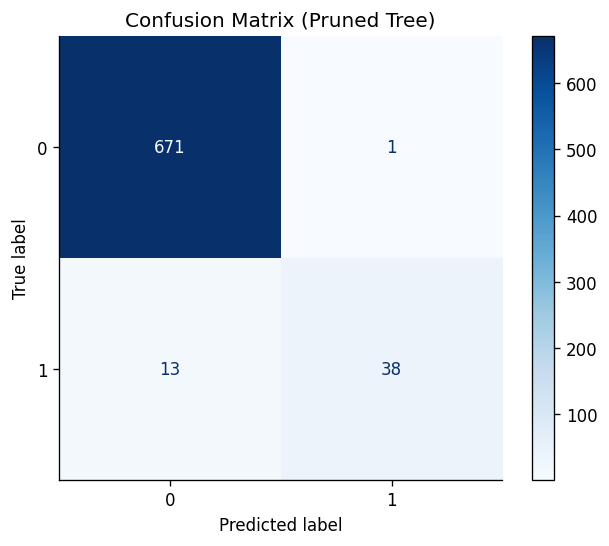

In [79]:
# 2. Predict
y_pred_pruned = tree_full.predict(X_test)

# 3. Confusion matrix
cm = confusion_matrix(y_test, y_pred_pruned)

# 4. Metrics
precision  = precision_score(y_test, y_pred_pruned)
recall     = recall_score(y_test, y_pred_pruned)
f1         = f1_score(y_test, y_pred_pruned)
acc_pruned = accuracy_score(y_test, y_pred_pruned)

# YOUR CODE HERE

print(f"Confusion Matrix:\n{cm}")
print(f"\nPrecision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"Accuracy:  {acc_pruned:.4f}")

# Visualize
ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap='Blues')
plt.title("Confusion Matrix (Pruned Tree)")
plt.show()

In [80]:
tn, fp, fn, tp = cm.ravel()
specificity = tn/(tn+fp)  # float
y_prob_pruned = tree_full.predict_proba(X_test)[:, 1]  # NumPy array, shape (90,)
brier   = brier_score_loss(y_test, y_prob_pruned)
logloss = log_loss(y_test, y_prob_pruned)

# YOUR CODE HERE

print(f"Specificity:  {specificity:.4f}")
print(f"Brier Score:  {brier:.4f} (lower is better)")
print(f"Log Loss:     {logloss:.4f} (lower is better)")

Specificity:  0.9985
Brier Score:  0.0197 (lower is better)
Log Loss:     0.1035 (lower is better)


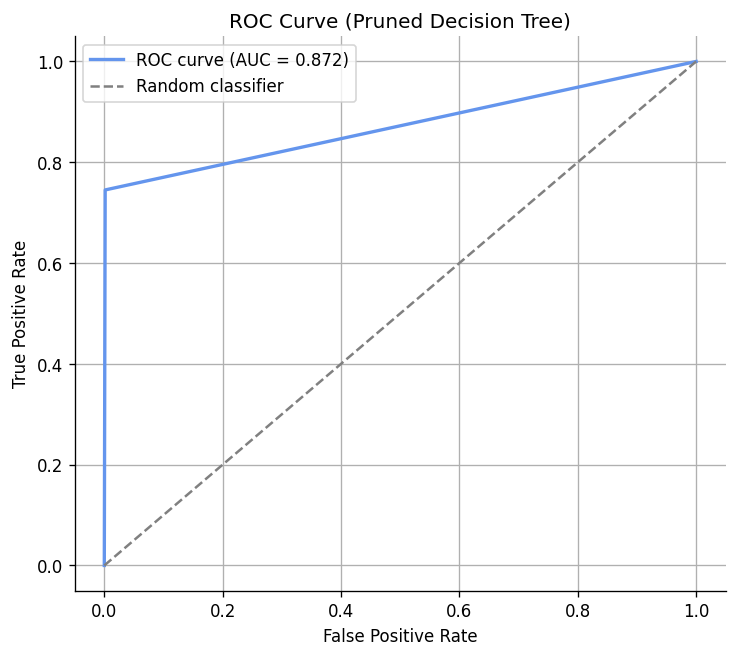

In [81]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_pruned)
auc_score = roc_auc_score(y_test, y_prob_pruned)  # float

# YOUR CODE HERE

# Plot (provided)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='cornflowerblue', linewidth=2, label=f'ROC curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (Pruned Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

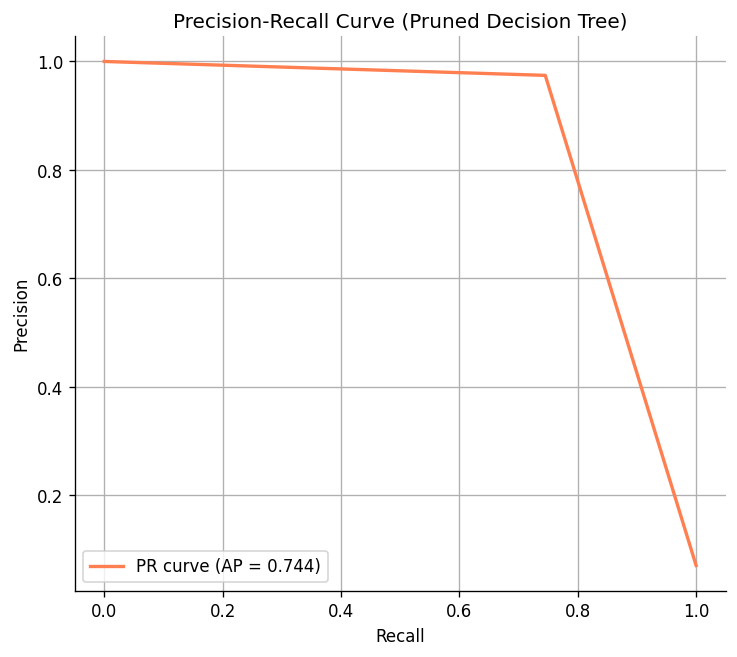

In [82]:
pr_precision, pr_recall, pr_thresholds = precision_recall_curve(y_test, y_prob_pruned)  # NumPy array
avg_precision = average_precision_score(y_test, y_prob_pruned)  # float

# YOUR CODE HERE

# Plot (provided)
plt.figure(figsize=(7, 6))
plt.plot(pr_recall, pr_precision, color='coral', linewidth=2,
         label=f'PR curve (AP = {avg_precision:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Pruned Decision Tree)')
plt.legend()
plt.grid(True)
plt.show()

In [83]:
# 1. Single Tree
dt_real = DecisionTreeClassifier(random_state=42)  # DecisionTreeClassifier
dt_real.fit(X_train, y_train)
acc_dt = accuracy_score(y_test, dt_real.predict(X_test))  # float

# 2. Random Forest
rf_real = RandomForestClassifier(random_state=42)  # RandomForestClassifier
rf_real.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf_real.predict(X_test))  # float

# YOUR CODE HERE

print(f"Single Decision Tree Accuracy: {acc_dt:.4f}")
print(f"Random Forest Accuracy:        {acc_rf:.4f}")

Single Decision Tree Accuracy: 0.9627
Random Forest Accuracy:        0.9793


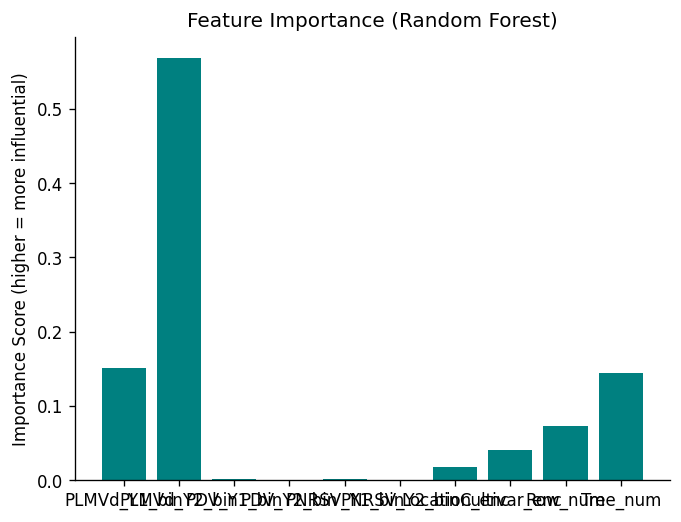

In [84]:
importances = rf_real.feature_importances_  # NumPy array, shape (4,)

# YOUR CODE HERE

# Visualization
plt.bar(FEATURE_COLS, importances, color='teal')
plt.title("Feature Importance (Random Forest)")
plt.ylabel("Importance Score (higher = more influential)")
plt.show()

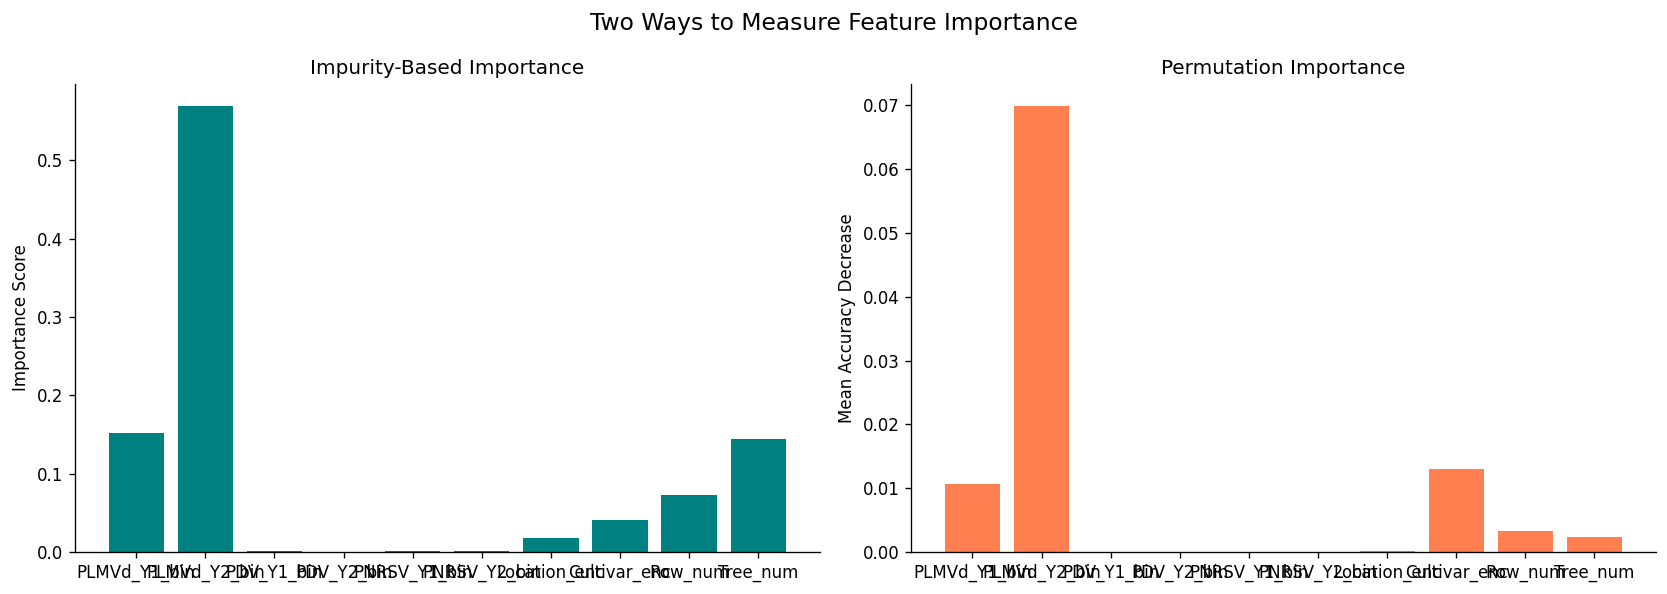

In [85]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(rf_real, X_test, y_test, n_repeats=10, random_state=42)  # PermutationImportance result object
perm_importances = perm_result.importances_mean  # NumPy array, shape (4,)

# YOUR CODE HERE

# Compare impurity-based vs permutation importance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(FEATURE_COLS, importances, color='teal')
axes[0].set_title("Impurity-Based Importance")
axes[0].set_ylabel("Importance Score")
axes[1].bar(FEATURE_COLS, perm_importances, color='coral')
axes[1].set_title("Permutation Importance")
axes[1].set_ylabel("Mean Accuracy Decrease")
plt.suptitle("Two Ways to Measure Feature Importance", fontsize=14)
plt.tight_layout()
plt.show()

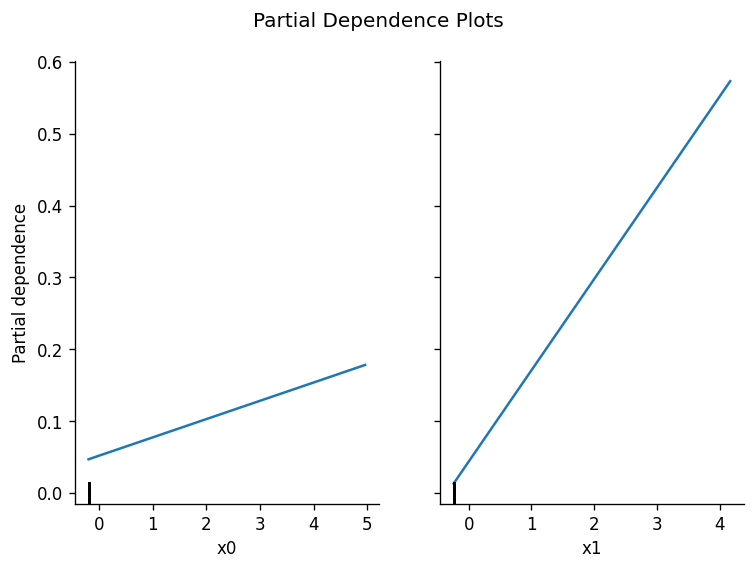

In [86]:
from sklearn.inspection import PartialDependenceDisplay

# PartialDependenceDisplay
pdp_display = PartialDependenceDisplay.from_estimator(estimator=rf_real ,X=X_train, features=[0, 1])

plt.suptitle('Partial Dependence Plots')
plt.tight_layout()
plt.show()

In [87]:
# 1. Standard RF (no class weighting)
rfc = RandomForestClassifier(random_state=42)
rfc.fit(X_train, y_train)

acc_imb = accuracy_score(y_test, rfc.predict(X_test))  # float
f1_imb = f1_score(y_test, rfc.predict(X_test))  # float
recall_imb = recall_score(y_test, rfc.predict(X_test))  # float

# 2. RF with class_weight='balanced'
rfc_balanced = RandomForestClassifier(random_state=42, class_weight='balanced')
rfc_balanced.fit(X_train, y_train)
acc_imb_bal = accuracy_score(y_test, rfc_balanced.predict(X_test))   # float
f1_imb_bal = f1_score(y_test, rfc_balanced.predict(X_test))   # float
recall_imb_bal = recall_score(y_test, rfc_balanced.predict(X_test))  # float

# YOUR CODE HERE

print(f"{'Model':<25} {'Accuracy':>10} {'F1':>10} {'Recall':>10}")
print(f"{'-'*55}")
print(f"{'Standard RF':<25} {acc_imb:>10.4f} {f1_imb:>10.4f} {recall_imb:>10.4f}")
print(f"{'Balanced RF':<25} {acc_imb_bal:>10.4f} {f1_imb_bal:>10.4f} {recall_imb_bal:>10.4f}")

Model                       Accuracy         F1     Recall
-------------------------------------------------------
Standard RF                   0.9793     0.8315     0.7255
Balanced RF                   0.9779     0.8222     0.7255


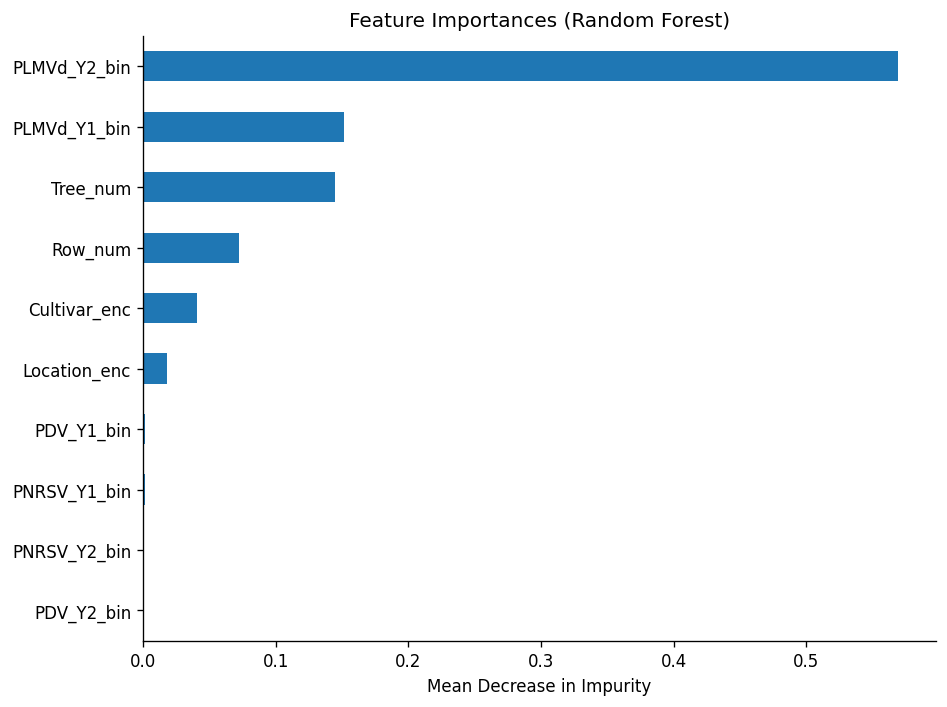

In [88]:
importances = pd.Series(rfc.feature_importances_, index=FEATURE_COLS)
importances.sort_values().plot(kind='barh', figsize=(8, 6))
plt.title("Feature Importances (Random Forest)")
plt.xlabel("Mean Decrease in Impurity")
plt.tight_layout()
plt.show()

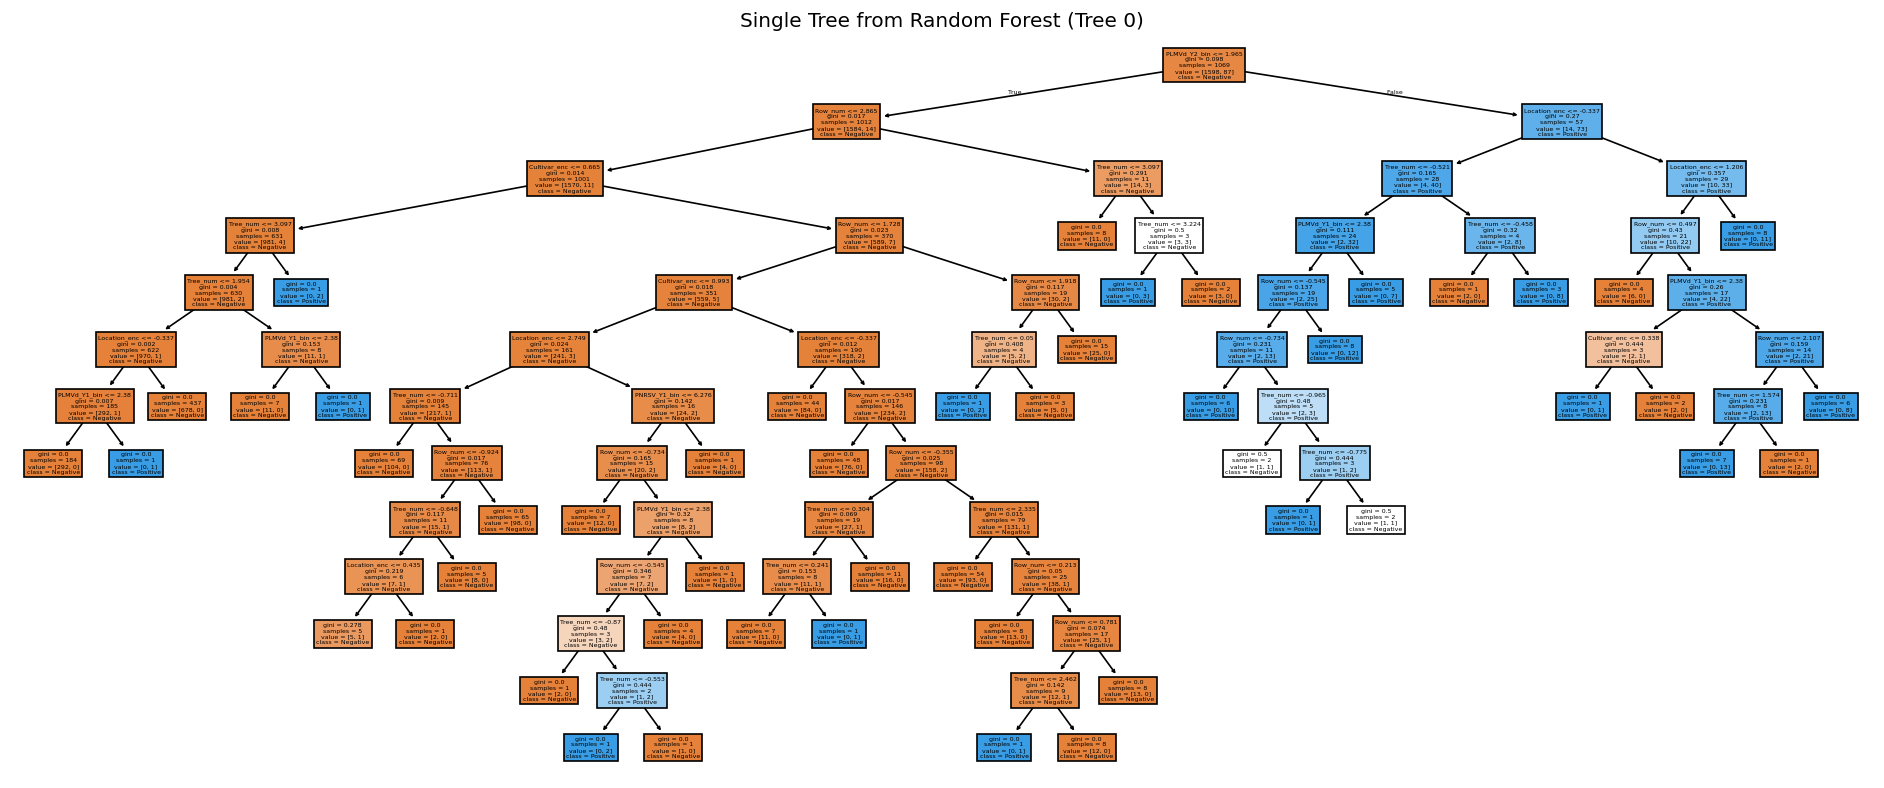

In [89]:
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(rfc.estimators_[0],          # first tree in the forest
          feature_names=FEATURE_COLS,
          class_names=['Negative', 'Positive'],
          filled=True,
          ax=ax)
plt.title("Single Tree from Random Forest (Tree 0)")
plt.show()

In [90]:
from sklearn.decomposition import PCA
from sklearn.svm import SVC

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X)

X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

svm_linear = SVC(kernel='linear', gamma=0.1)
svm_rbf    = SVC(kernel='rbf', gamma=0.1)

svm_linear.fit(X_train_2d, y_train_2d)
svm_rbf.fit(X_train_2d, y_train_2d)

acc_linear = svm_linear.score(X_test_2d, y_test_2d)
acc_rbf    = svm_rbf.score(X_test_2d, y_test_2d)

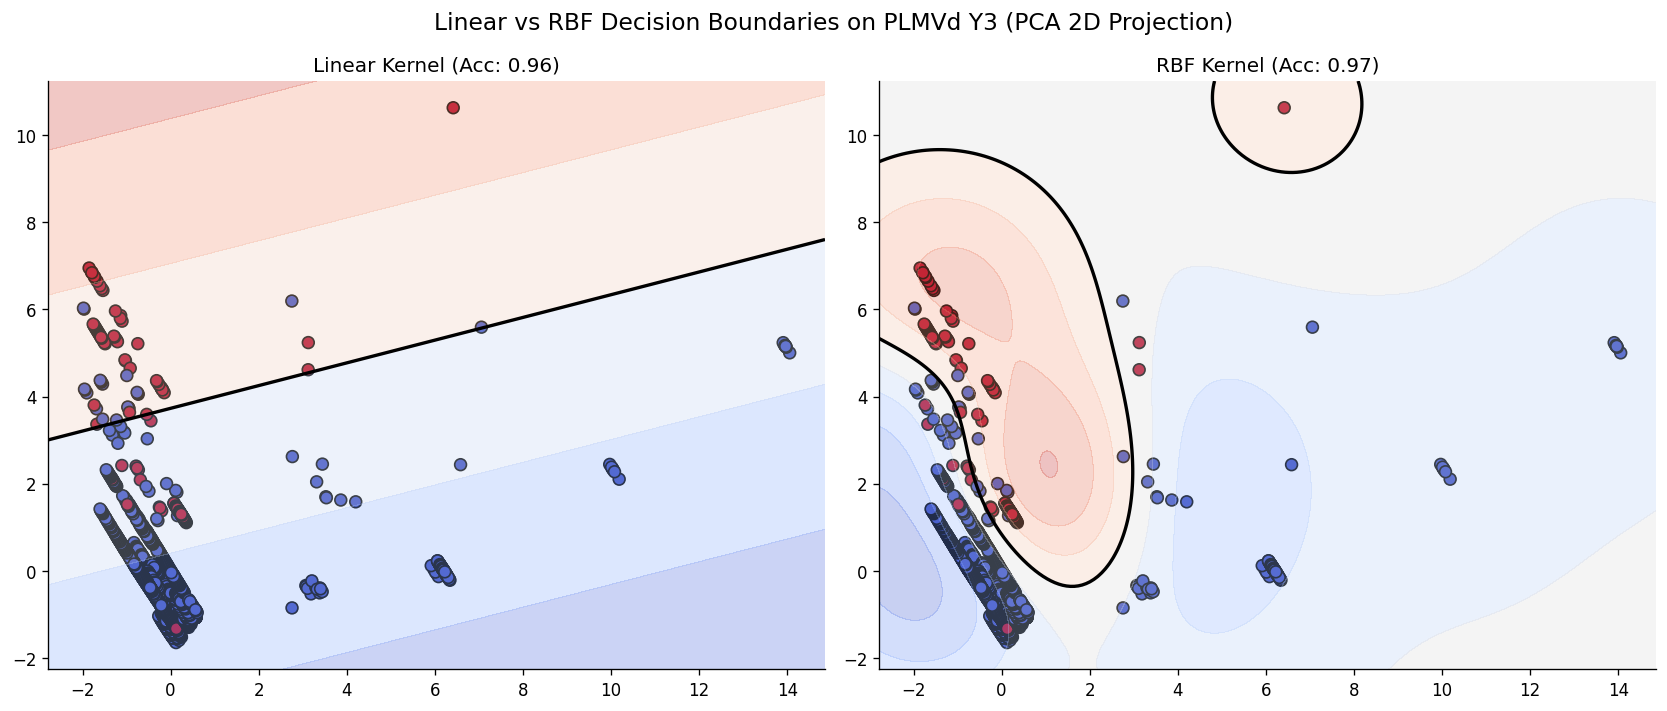

In [91]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for model, ax, title in [(svm_linear, ax1, f'Linear Kernel (Acc: {acc_linear:.2f})'),
                          (svm_rbf,    ax2, f'RBF Kernel (Acc: {acc_rbf:.2f})')]:
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=50)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 200)
    yy = np.linspace(ylim[0], ylim[1], 200)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contourf(XX, YY, Z, alpha=0.3, cmap='coolwarm')
    ax.contour(XX, YY, Z, colors='k', levels=[0], linewidths=2)
    ax.set_title(title)

plt.suptitle('Linear vs RBF Decision Boundaries on PLMVd Y3 (PCA 2D Projection)', fontsize=14)
plt.tight_layout()
plt.show()

In [92]:
from sklearn.model_selection import GridSearchCV 
# 1. Parameter grid
param_grid = {'C': [0.1, 1, 10, 100], 'gamma': [0.01, 0.1, 1, 10]}

# 2-3. Grid search
grid_search = GridSearchCV(SVC(kernel='rbf'), cv=5, param_grid=param_grid)  # GridSearchCV object
grid_search.fit(X_train, y_train)

# 4. Results
best_params = grid_search.best_params_  # dict
best_cv_score = grid_search.best_score_  # float
grid_test_acc = grid_search.score(X_test, y_test)  # float

# YOUR CODE HERE

print(f"Best parameters: {best_params}")
print(f"Best CV score: {best_cv_score:.4f}")
print(f"Test accuracy: {grid_test_acc:.4f}")

Best parameters: {'C': 1, 'gamma': 0.1}
Best CV score: 0.9852
Test accuracy: 0.9779


SVR R² Score: -0.0087


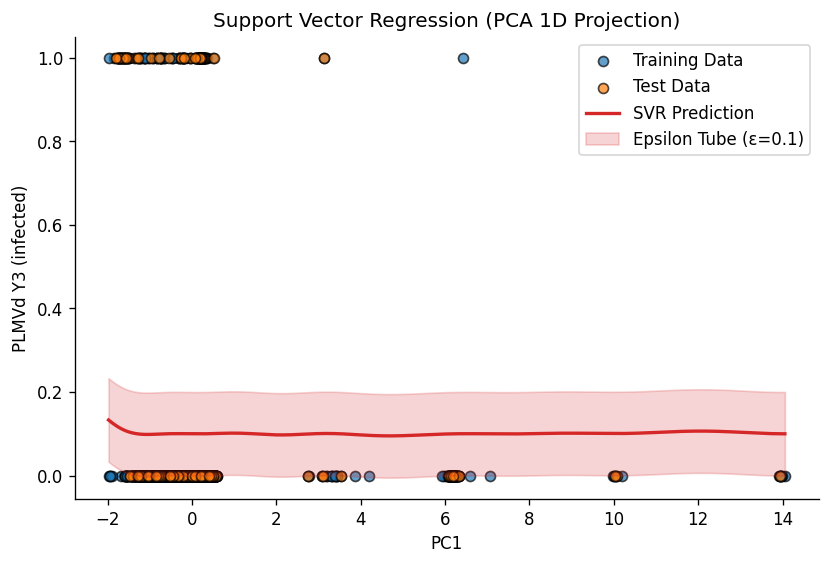

In [94]:
from sklearn.metrics import r2_score
from sklearn.decomposition import PCA
from sklearn.svm import SVR

# Reduce to 1 component for visualization
pca_1d = PCA(n_components=1)
X_1d = pca_1d.fit_transform(X)

X_train_1d, X_test_1d, y_train_1d, y_test_1d = train_test_split(
    X_1d, y, test_size=0.2, random_state=42
)

# 1. Fit SVR on 1D data
svr_model = SVR(kernel='rbf')
svr_model.fit(X_train_1d, y_train_1d)
svr_r2 = r2_score(y_test_1d, svr_model.predict(X_test_1d))

print(f"SVR R² Score: {svr_r2:.4f}")

# --- Visualization ---
X_plot = np.linspace(X_1d.min(), X_1d.max(), 300).reshape(-1, 1)
y_plot = svr_model.predict(X_plot)

plt.figure(figsize=(8, 5))
plt.scatter(X_train_1d, y_train_1d, color='C0', label='Training Data', edgecolors='k', alpha=0.7)
plt.scatter(X_test_1d,  y_test_1d,  color='C1', label='Test Data',     edgecolors='k', alpha=0.7)
plt.plot(X_plot, y_plot, color='C3', lw=2, label='SVR Prediction')
plt.fill_between(X_plot.ravel(),
                 y_plot - svr_model.epsilon,
                 y_plot + svr_model.epsilon,
                 alpha=0.2, color='C3', label=f'Epsilon Tube (ε={svr_model.epsilon})')
plt.title('Support Vector Regression (PCA 1D Projection)')
plt.xlabel('PC1')
plt.ylabel('PLMVd Y3 (infected)')
plt.legend()
plt.show()

Poly degree=2: 0.9606
Poly degree=3: 0.9606
Poly degree=5: 0.9606
Best degree: 2


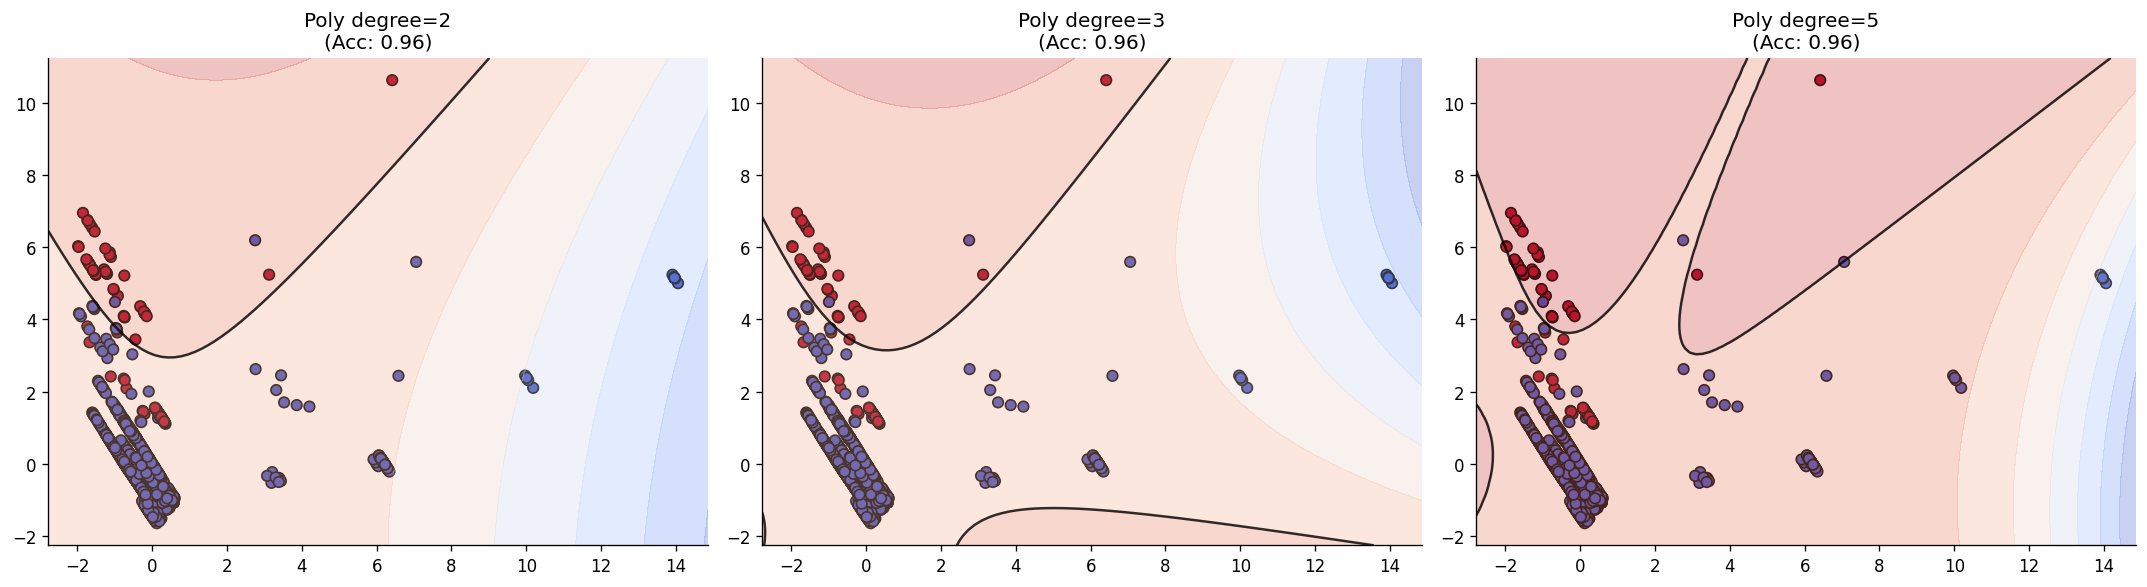

In [95]:
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(
    X_2d, y, test_size=0.2, random_state=42
)

# 1. Train polynomial SVMs
svm_poly2 = SVC(kernel='poly', degree=2)  # SVC object, degree=2
svm_poly3 = SVC(kernel='poly', degree=3)  # SVC object, degree=3
svm_poly5 = SVC(kernel='poly', degree=5)  # SVC object, degree=5

svm_poly2.fit(X_train_2d, y_train_2d)
svm_poly3.fit(X_train_2d, y_train_2d)
svm_poly5.fit(X_train_2d, y_train_2d)

# 2. Test accuracies
acc_poly2 = svm_poly2.score(X_test_2d, y_test_2d)  # float
acc_poly3 = svm_poly3.score(X_test_2d, y_test_2d)  # float
acc_poly5 = svm_poly5.score(X_test_2d, y_test_2d)  # float

# 3. Best degree
best_degree = 2  # int (2, 3, or 5)

# YOUR CODE HERE

print(f"Poly degree=2: {acc_poly2:.4f}")
print(f"Poly degree=3: {acc_poly3:.4f}")
print(f"Poly degree=5: {acc_poly5:.4f}")
print(f"Best degree: {best_degree}")

# --- Visualization Code ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, model, deg, acc in zip(axes,
                                [svm_poly2, svm_poly3, svm_poly5],
                                [2, 3, 5],
                                [acc_poly2, acc_poly3, acc_poly5]):
    ax.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train_2d, cmap='coolwarm', edgecolors='k', s=40)
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    xx = np.linspace(xlim[0], xlim[1], 100)
    yy = np.linspace(ylim[0], ylim[1], 100)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.decision_function(xy).reshape(XX.shape)
    ax.contour(XX, YY, Z, colors='k', levels=[0], alpha=0.8)
    ax.contourf(XX, YY, Z, alpha=0.3, cmap='coolwarm')
    ax.set_title(f'Poly degree={deg}\n(Acc: {acc:.2f})')
plt.tight_layout()
plt.show()

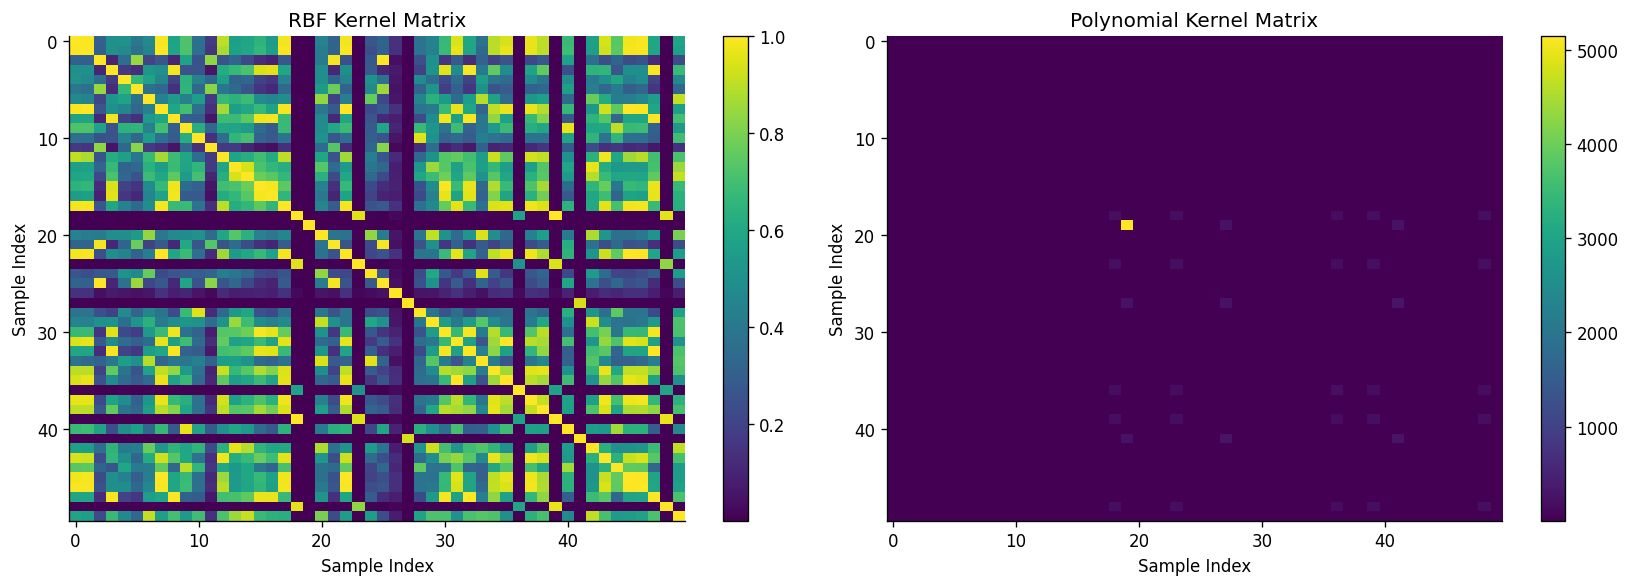

In [96]:
from sklearn.metrics.pairwise import pairwise_kernels

# 1. Subset
X_sub = X_train[:50]

# 2. RBF kernel matrix
K_rbf = pairwise_kernels(X_sub, metric='rbf')  # 50x50 NumPy array

# 3. Polynomial kernel matrix
K_poly = pairwise_kernels(X_sub, metric='poly')  # 50x50 NumPy array

# YOUR CODE HERE

# --- Visualization Code ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

im1 = ax1.imshow(K_rbf, cmap='viridis', aspect='auto')
ax1.set_title('RBF Kernel Matrix')
ax1.set_xlabel('Sample Index')
ax1.set_ylabel('Sample Index')
plt.colorbar(im1, ax=ax1)

im2 = ax2.imshow(K_poly, cmap='viridis', aspect='auto')
ax2.set_title('Polynomial Kernel Matrix')
ax2.set_xlabel('Sample Index')
ax2.set_ylabel('Sample Index')
plt.colorbar(im2, ax=ax2)

plt.tight_layout()
plt.show()

## Target transition trees

In [97]:
newly_infected = df[
    ((df['PDV_Y1']   == '-') & (df['PDV_Y2']   == '+')) |
    ((df['PNRSV_Y1'] == '-') & (df['PNRSV_Y2'] == '+')) |
    ((df['PLMVd_Y1'] == '-') & (df['PLMVd_Y2'] == '+'))
].copy().reset_index(drop=True)

In [98]:
VIRUS_COLS = [
    'PDV_Y1',   'PDV_Y2',   'PDV_Y3',
    'PNRSV_Y1', 'PNRSV_Y2', 'PNRSV_Y3',
    'PLMVd_Y1', 'PLMVd_Y2', 'PLMVd_Y3',
]
for col in VIRUS_COLS:
    newly_infected[col + '_bin'] = (newly_infected[col] == '+').astype(int)

# --- Encode Location ---
le_loc = LabelEncoder()
newly_infected['Location_enc'] = le_loc.fit_transform(newly_infected['Location'])

# --- Encode Cultivar: top-10 + "Other" ---
top10_cultivars = newly_infected['Cultivar'].value_counts().head(10).index.tolist()
newly_infected['Cultivar_grp'] = newly_infected['Cultivar'].apply(
    lambda x: x if x in top10_cultivars else 'Other'
)
le_cult = LabelEncoder()
newly_infected['Cultivar_enc'] = le_cult.fit_transform(newly_infected['Cultivar_grp'])

newly_infected['Row_num']  = pd.to_numeric(newly_infected['Row'],  errors='coerce').fillna(0)
newly_infected['Tree_num'] = pd.to_numeric(newly_infected['Tree'], errors='coerce').fillna(0)

FEATURE_INFECTED_COLS = [
    'PLMVd_Y1_bin',
    'PDV_Y1_bin',
    'PNRSV_Y1_bin',
    'Location_enc', 'Cultivar_enc',
    'Row_num', 'Tree_num',
]

X_infected_raw = newly_infected[FEATURE_INFECTED_COLS].values
y_infected     = newly_infected['PLMVd_Y2_bin'].values  # Y2 as target

scaler = StandardScaler()
X_infected = scaler.fit_transform(X_infected_raw)

print(f"Feature matrix: {X_infected.shape}")
print(f"Positive (PLMVd Y2): {y_infected.sum()} / {len(y_infected)}  ({y_infected.mean()*100:.1f}%)")

Feature matrix: (85, 7)
Positive (PLMVd Y2): 66 / 85  (77.6%)


In [99]:
X_train_infected, X_test_infected, y_train_infected, y_test_infected = train_test_split(
    X_infected, y_infected, test_size=0.2, random_state=42, stratify=y_infected
)

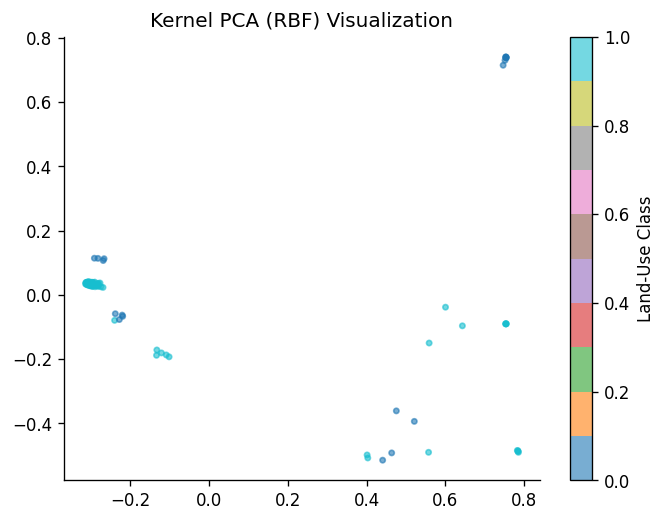

In [100]:
# 1. Initialize
kpca = KernelPCA(n_components=2, kernel='rbf', random_state=42)  # KernelPCA

# 2. Fit Transform
X_kpca = kpca.fit_transform(X_infected)

# YOUR CODE HERE

plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y_infected, cmap='tab10', s=10, alpha=0.6)
plt.colorbar(label='Land-Use Class')
plt.title("Kernel PCA (RBF) Visualization")
plt.show()

In [101]:
n_samples, n_features = X_infected.shape

pca = PCA(n_components=3)
X_transformed = pca.fit_transform(X_infected)

print(f"{7} principal components explain {pca.explained_variance_ratio_.sum()*100:.2f}% of the variance.")

# We center the data and compute the sample covariance matrix.
X_centered = X_infected - np.mean(X_infected, axis=0)
cov_matrix = np.dot(X_centered.T, X_centered) / n_samples
eigenvalues = pca.explained_variance_
for i, (eigenvalue, eigenvector) in enumerate(zip(eigenvalues, pca.components_)):
    print(f"\nPC{i+1} â€” eigenvalue: {eigenvalue:.6f}")
    print(f"  verification dot product: {np.dot(eigenvector.T, np.dot(cov_matrix, eigenvector)):.6f}")
    for feature, loading in zip(FEATURE_COLS, eigenvector):
        print(f"  {feature}: {loading:.6f}")

7 principal components explain 81.32% of the variance.

PC1 â€” eigenvalue: 2.002499
  verification dot product: 1.978940
  PLMVd_Y1_bin: 0.000000
  PLMVd_Y2_bin: 0.213214
  PDV_Y1_bin: -0.405267
  PDV_Y2_bin: -0.520292
  PNRSV_Y1_bin: 0.615877
  PNRSV_Y2_bin: 0.284294
  Location_enc: 0.243859

PC2 â€” eigenvalue: 1.928522
  verification dot product: 1.905834
  PLMVd_Y1_bin: -0.000000
  PLMVd_Y2_bin: -0.184625
  PDV_Y1_bin: 0.091307
  PDV_Y2_bin: 0.370071
  PNRSV_Y1_bin: -0.108204
  PNRSV_Y2_bin: 0.628210
  Location_enc: 0.643637

PC3 â€” eigenvalue: 1.006264
  verification dot product: 0.994425
  PLMVd_Y1_bin: 0.000000
  PLMVd_Y2_bin: 0.839210
  PDV_Y1_bin: 0.487031
  PDV_Y2_bin: 0.177668
  PNRSV_Y1_bin: 0.142140
  PNRSV_Y2_bin: 0.012416
  Location_enc: 0.081258


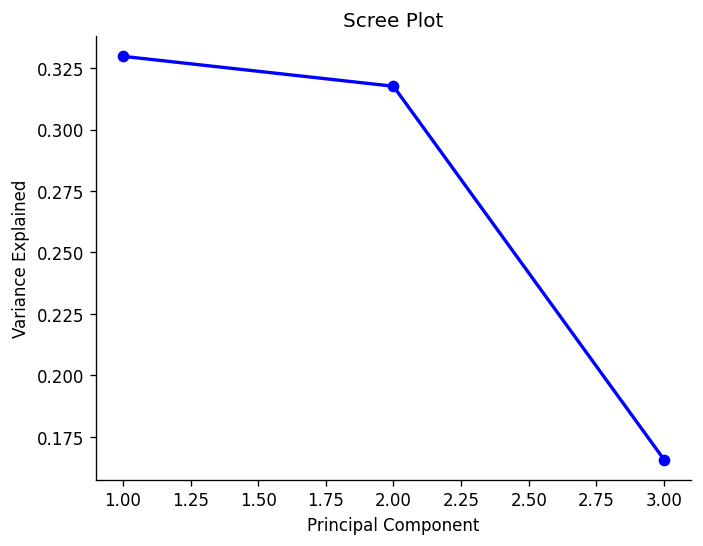

In [103]:
PC_values = np.arange(pca.n_components_) + 1
plt.plot(PC_values, pca.explained_variance_ratio_, 'o-', linewidth=2, color='blue')
plt.title('Scree Plot')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.show()

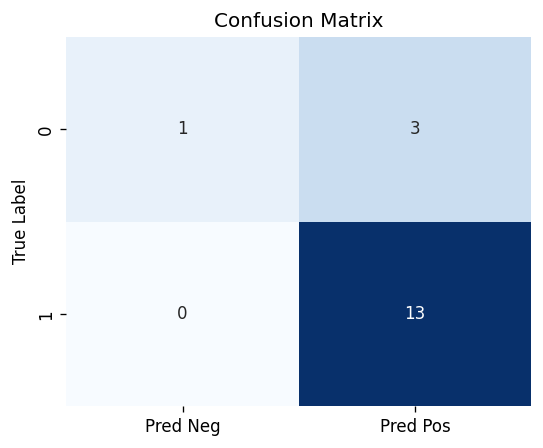

In [104]:
model = LogisticRegression()
model.fit(X_train_infected, y_train_infected)

y_pred = model.predict(X_test_infected)

cm = confusion_matrix(y_test_infected, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred Neg', 'Pred Pos'],)
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

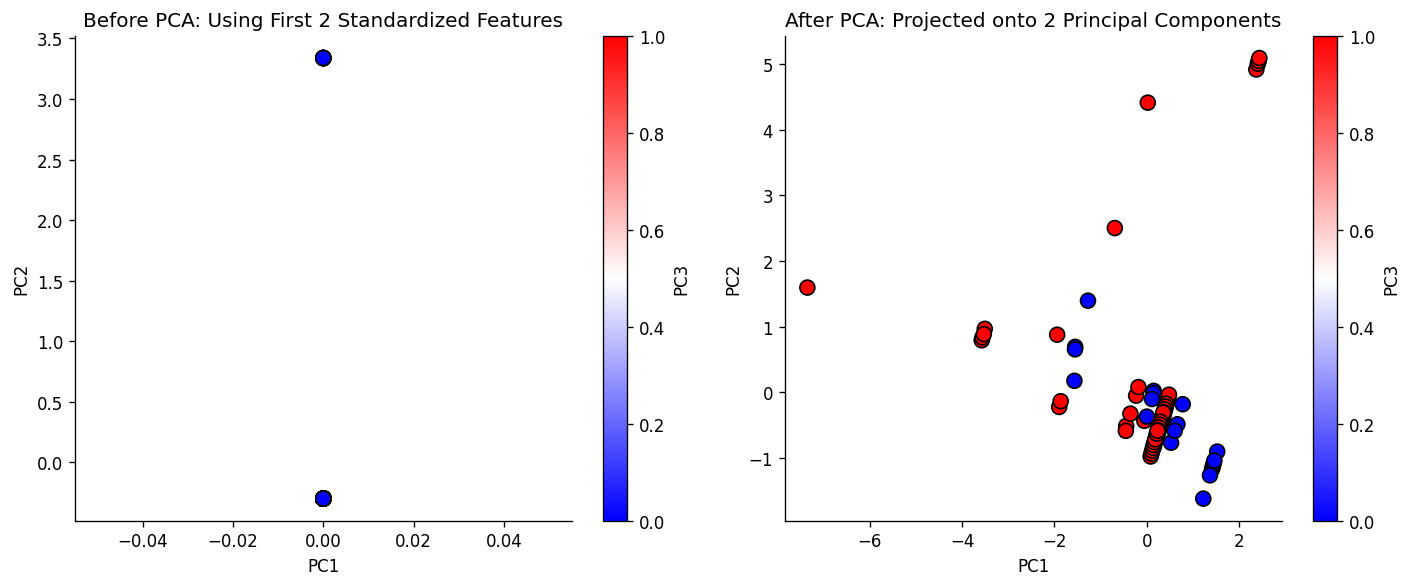

In [105]:
y_numeric = pd.factorize(y_infected)[0]

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_infected[:, 0], X_infected[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Before PCA: Using First 2 Standardized Features')
plt.colorbar(label='PC3')

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:, 0], X_transformed[:, 1], c=y_numeric, cmap='bwr', edgecolor='k', s=80)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('After PCA: Projected onto 2 Principal Components')
plt.colorbar(label='PC3')

plt.tight_layout()
plt.show()

In [106]:
from scipy.spatial.distance import cdist
# ── 1. Build coordinate arrays ──────────────────────────────────────────────
coords = df[['Row_num', 'Tree_num']].values  # shape (2408, 2)

results = {}

for virus in ['PDV', 'PNRSV', 'PLMVd']:
    y1_col = f'{virus}_Y1'
    y2_col = f'{virus}_Y2'

    # ── 2. Identify Y1 infected trees (potential sources) ───────────────────
    infected_y1_mask  = df[y1_col] == '+'
    healthy_y1_mask   = df[y1_col] == '-'

    infected_coords   = coords[infected_y1_mask]   # source trees
    healthy_coords    = coords[healthy_y1_mask]     # trees at risk

    # ── 3. Calculate distance from each healthy tree to nearest infected tree
    if len(infected_coords) == 0:
        print(f"{virus}: No Y1 infections found, skipping.")
        continue

    dist_matrix = cdist(healthy_coords, infected_coords, metric='euclidean')
    min_dist    = dist_matrix.min(axis=1)  # distance to nearest infected neighbor

    # ── 4. Build modelling dataframe ────────────────────────────────────────
    healthy_df = df[healthy_y1_mask].copy().reset_index(drop=True)
    healthy_df['min_dist_to_infected'] = min_dist
    healthy_df['became_infected_y2']   = (healthy_df[y2_col] == '+').astype(int)

    print(f"\n{'─'*50}")
    print(f"{virus} — Y1 healthy trees: {len(healthy_df)}")
    print(f"  Became infected in Y2: {healthy_df['became_infected_y2'].sum()} "
          f"({healthy_df['became_infected_y2'].mean()*100:.1f}%)")
    print(f"  Distance to nearest infected — "
          f"mean: {min_dist.mean():.2f}, min: {min_dist.min():.2f}, max: {min_dist.max():.2f}")

    results[virus] = healthy_df

print("\nDone — results dict has keys:", list(results.keys()))


──────────────────────────────────────────────────
PDV — Y1 healthy trees: 2318
  Became infected in Y2: 8 (0.3%)
  Distance to nearest infected — mean: 10.42, min: 0.00, max: 64.29

──────────────────────────────────────────────────
PNRSV — Y1 healthy trees: 2393
  Became infected in Y2: 12 (0.5%)
  Distance to nearest infected — mean: 7.92, min: 0.00, max: 54.42

──────────────────────────────────────────────────
PLMVd — Y1 healthy trees: 2314
  Became infected in Y2: 66 (2.9%)
  Distance to nearest infected — mean: 2.31, min: 0.00, max: 13.15

Done — results dict has keys: ['PDV', 'PNRSV', 'PLMVd']


PDV — Logistic Regression Accuracy: 0.997
PNRSV — Logistic Regression Accuracy: 0.995
PLMVd — Logistic Regression Accuracy: 0.971


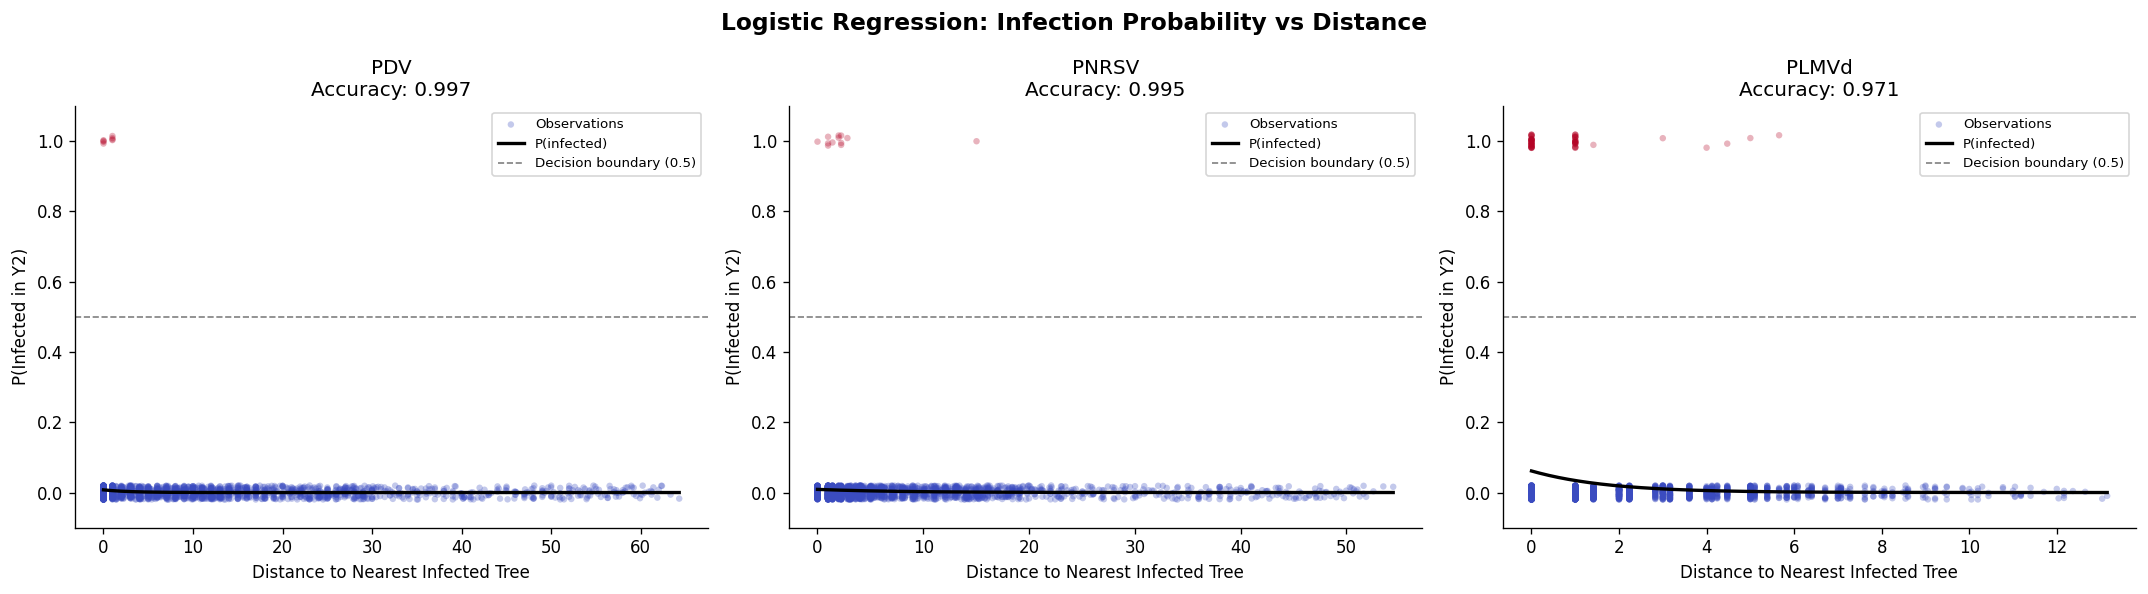

In [107]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (virus, df_virus) in zip(axes, results.items()):
    X = df_virus[['min_dist_to_infected']].values
    y = df_virus['became_infected_y2'].values

    lr = LogisticRegression()
    lr.fit(X, y)
    acc = lr.score(X, y)

    print(f"{virus} — Logistic Regression Accuracy: {acc:.3f}")

    # Smooth curve for the logistic regression line
    x_range = np.linspace(X.min(), X.max(), 300).reshape(-1, 1)
    y_prob   = lr.predict_proba(x_range)[:, 1]

    # Jitter y values slightly so overlapping points are visible
    jitter = np.random.uniform(-0.02, 0.02, size=len(y))

    ax.scatter(X, y + jitter, s=15, alpha=0.3, c=y, cmap='coolwarm', edgecolors='none', label='Observations')
    ax.plot(x_range, y_prob, color='black', linewidth=2, label='P(infected)')
    ax.axhline(0.5, color='grey', linestyle='--', linewidth=1, label='Decision boundary (0.5)')

    ax.set_title(f'{virus}\nAccuracy: {acc:.3f}', fontsize=12)
    ax.set_xlabel('Distance to Nearest Infected Tree')
    ax.set_ylabel('P(Infected in Y2)')
    ax.set_ylim(-0.1, 1.1)
    ax.legend(fontsize=8)

plt.suptitle('Logistic Regression: Infection Probability vs Distance', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('logistic_regression_curves.png', dpi=150, bbox_inches='tight')
plt.show()

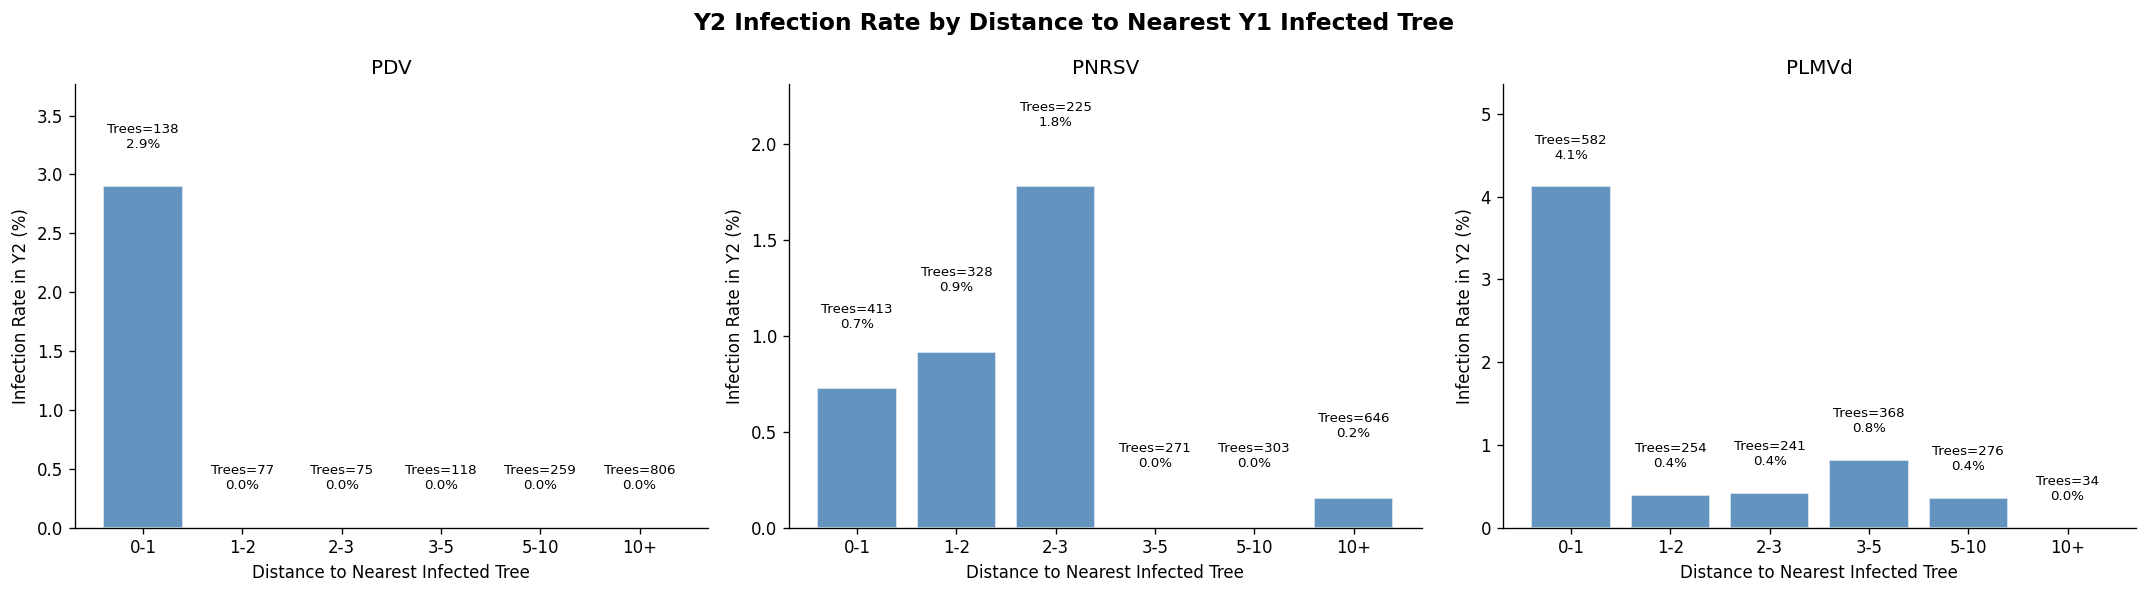

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (virus, df_virus) in zip(axes, results.items()):
    X = df_virus[['min_dist_to_infected']].values
    y = df_virus['became_infected_y2'].values

    lr = LogisticRegression()
    lr.fit(X, y)

    # Bin distances and get mean infection rate per bin
    df_v = df_virus.copy()
    df_v['became_infected_y2'] = y
    df_v['dist_bin'] = pd.cut(df_v['min_dist_to_infected'],
                               bins=[0, 1, 2, 3, 5, 10, 999],
                               labels=['0-1', '1-2', '2-3', '3-5', '5-10', '10+'],
                               right=True)

    bin_stats = df_v.groupby('dist_bin', observed=True)['became_infected_y2'].agg(['mean', 'count'])
    bin_stats['pct'] = bin_stats['mean'] * 100

    bars = ax.bar(bin_stats.index.astype(str), bin_stats['pct'],
                  color='steelblue', edgecolor='white', alpha=0.85)

    # Annotate bars with count and percentage
    for bar, (_, row) in zip(bars, bin_stats.iterrows()):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.3,
                f'Trees={int(row["count"])}\n{row["pct"]:.1f}%',
                ha='center', va='bottom', fontsize=8)

    ax.set_title(f'{virus}', fontsize=12)
    ax.set_xlabel('Distance to Nearest Infected Tree')
    ax.set_ylabel('Infection Rate in Y2 (%)')
    ax.set_ylim(0, bin_stats['pct'].max() * 1.3)

plt.suptitle('Y2 Infection Rate by Distance to Nearest Y1 Infected Tree',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('infection_rate_bar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

In [109]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

for virus, df_virus in results.items():
    X = df_virus[['min_dist_to_infected']].values
    y = df_virus['became_infected_y2'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    lr = LogisticRegression(class_weight='balanced', max_iter=1000)
    lr.fit(X_train, y_train)

    train_auc = roc_auc_score(y_train, lr.predict_proba(X_train)[:, 1])
    test_auc  = roc_auc_score(y_test,  lr.predict_proba(X_test)[:, 1])

    print(f"{virus}  →  Train AUC: {train_auc:.3f}  |  Test AUC: {test_auc:.3f}  |  Gap: {train_auc - test_auc:.3f}")

PDV  →  Train AUC: 0.708  |  Test AUC: 0.729  |  Gap: -0.021
PNRSV  →  Train AUC: 0.676  |  Test AUC: 0.555  |  Gap: 0.121
PLMVd  →  Train AUC: 0.754  |  Test AUC: 0.675  |  Gap: 0.079


Random forest


──────────────────────────────────────────────────
PDV
  CV AUC scores: [0.729 0.74  0.482 0.462 0.474]
  Mean AUC:      0.577 ± 0.129
             Feature  Importance
min_dist_to_infected       0.192
             Row_num       0.219
        Location_enc       0.267
            Tree_num       0.322

──────────────────────────────────────────────────
PNRSV
  CV AUC scores: [0.442 0.468 0.631 0.451 0.722]
  Mean AUC:      0.543 ± 0.113
             Feature  Importance
        Location_enc       0.089
            Tree_num       0.259
min_dist_to_infected       0.289
             Row_num       0.363

──────────────────────────────────────────────────
PLMVd
  CV AUC scores: [0.503 0.554 0.696 0.537 0.516]
  Mean AUC:      0.561 ± 0.070
             Feature  Importance
        Location_enc       0.151
min_dist_to_infected       0.217
             Row_num       0.236
            Tree_num       0.395


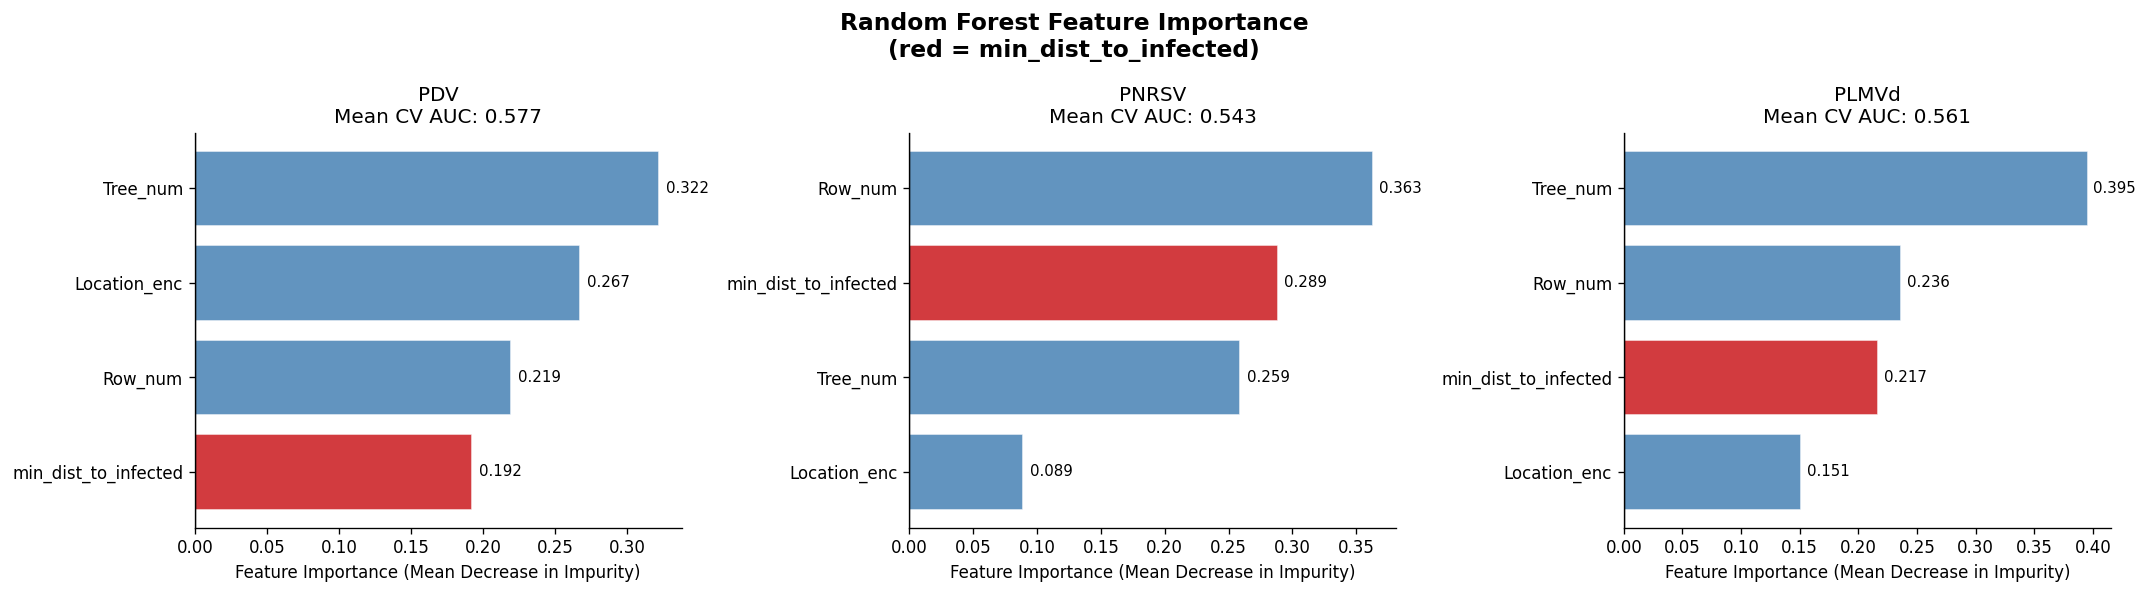

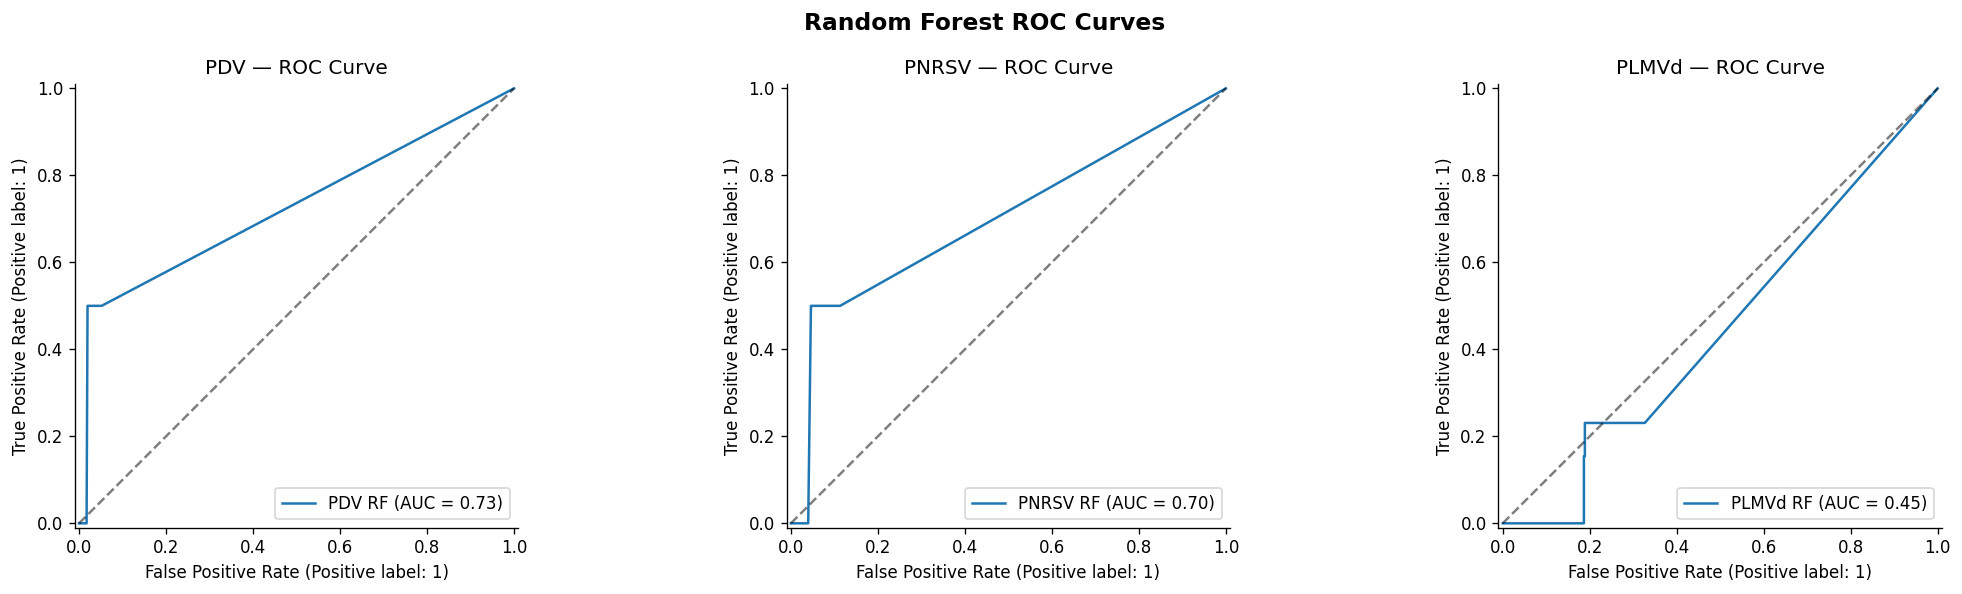

In [110]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

fig_imp, axes_imp = plt.subplots(1, 3, figsize=(18, 5))
fig_roc, axes_roc = plt.subplots(1, 3, figsize=(18, 5))

for ax_imp, ax_roc, virus in zip(axes_imp, axes_roc, ['PDV', 'PNRSV', 'PLMVd']):
    df_v = results[virus].copy()

    # ── Encode location ──────────────────────────────────────────────────────
    le = LabelEncoder()
    df_v['Location_enc'] = le.fit_transform(df_v['Location'])

    feature_cols = ['min_dist_to_infected', 'Row_num', 'Tree_num', 'Location_enc']
    X_v = df_v[feature_cols].values
    y_v = df_v['became_infected_y2'].values

    # ── Cross-validated AUC ──────────────────────────────────────────────────
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    rf = RandomForestClassifier(
        n_estimators=500,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )
    auc_scores = cross_val_score(rf, X_v, y_v, cv=cv, scoring='roc_auc')

    print(f"\n{'─'*50}")
    print(f"{virus}")
    print(f"  CV AUC scores: {np.round(auc_scores, 3)}")
    print(f"  Mean AUC:      {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")

    # ── Fit on full data for feature importance ──────────────────────────────
    rf.fit(X_v, y_v)

    importance_df = pd.DataFrame({
        'Feature'   : feature_cols,
        'Importance': rf.feature_importances_
    }).sort_values('Importance', ascending=True)

    print(importance_df.round(3).to_string(index=False))

    # ── Plot: feature importance ─────────────────────────────────────────────
    colors = ['#cb181d' if f == 'min_dist_to_infected' else 'steelblue'
              for f in importance_df['Feature']]
    bars = ax_imp.barh(importance_df['Feature'], importance_df['Importance'],
                       color=colors, edgecolor='white', alpha=0.85)
    ax_imp.set_title(f'{virus}\nMean CV AUC: {auc_scores.mean():.3f}', fontsize=12)
    ax_imp.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
    ax_imp.axvline(0, color='black', linewidth=0.8)

    # Annotate bars
    for bar in bars:
        ax_imp.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                    f'{bar.get_width():.3f}', va='center', fontsize=9)

    # ── Plot: ROC curve ──────────────────────────────────────────────────────
    X_train_v, X_test_v, y_train_v, y_test_v = train_test_split(
        X_v, y_v, test_size=0.2, stratify=y_v, random_state=42
    )
    rf.fit(X_train_v, y_train_v)
    RocCurveDisplay.from_estimator(rf, X_test_v, y_test_v, ax=ax_roc,
                                   name=f'{virus} RF')
    ax_roc.plot([0,1],[0,1], 'k--', alpha=0.5)
    ax_roc.set_title(f'{virus} — ROC Curve', fontsize=12)

fig_imp.suptitle('Random Forest Feature Importance\n(red = min_dist_to_infected)',
                 fontsize=14, fontweight='bold')
fig_imp.tight_layout()
fig_imp.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')

fig_roc.suptitle('Random Forest ROC Curves', fontsize=14, fontweight='bold')
fig_roc.tight_layout()
fig_roc.savefig('rf_roc_curves.png', dpi=150, bbox_inches='tight')

plt.show()

In [111]:
# Random Forest — alternative to Logistic Regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Train the model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_infected, y_train_infected)

# Make predictions
rf_pred = rf_model.predict(X_test_infected)

# Evaluate
print("Random Forest Accuracy:", accuracy_score(y_test_infected, rf_pred))
print()
print("Confusion Matrix:")
print(confusion_matrix(y_test_infected, rf_pred))
print()
print("Classification Report:")
print(classification_report(y_test_infected, rf_pred))


Random Forest Accuracy: 1.0

Confusion Matrix:
[[ 4  0]
 [ 0 13]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00        13

    accuracy                           1.00        17
   macro avg       1.00      1.00      1.00        17
weighted avg       1.00      1.00      1.00        17

